In [1]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAXResults

# Load the saved SARIMAX model results
model = SARIMAXResults.load('/Users/weitaochen/Downloads/SARIMAX.pkl')




ModuleNotFoundError: No module named 'numpy._core'

In [2]:
# Set TensorFlow threading optimizations before importing it
os.environ["TF_INTER_OP_PARALLELISM_THREADS"] = "4"
os.environ["TF_INTRA_OP_PARALLELISM_THREADS"] = "4"

# Load Data
fedfunds_data = pd.read_csv('/Users/weitaochen/Downloads/FEDFUNDS.csv')
walmart_data = pd.read_csv('/Users/weitaochen/Downloads/Walmart.csv')

In [3]:
# Convert date columns to datetime
fedfunds_data['observation_date'] = pd.to_datetime(fedfunds_data['observation_date'])
walmart_data['Date'] = pd.to_datetime(walmart_data['Date'], format='%d-%m-%Y')

# Rename FEDFUNDS date column
fedfunds_data.rename(columns={'observation_date': 'Date'}, inplace=True)

# Clean data
walmart_data = walmart_data.drop_duplicates().dropna()
fedfunds_data = fedfunds_data.drop_duplicates().dropna()

# Merge datasets
merged_data = pd.merge(walmart_data, fedfunds_data, on='Date', how='inner')

# Define target and features
target_column = 'Weekly_Sales'
features = merged_data.drop(columns=[target_column, 'Date'])
target = merged_data[target_column]

# Feature Engineering: Adding Time-based Features
merged_data['Month'] = merged_data['Date'].dt.month
merged_data['WeekOfYear'] = merged_data['Date'].dt.isocalendar().week
features = merged_data.drop(columns=[target_column, 'Date'])

# Feature Importance Analysis
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(features, target)

# Define feature importance
feature_importance = pd.Series(rf.feature_importances_, index=features.columns)

# Keep only the top 7 important features
top_features = feature_importance.nlargest(7).index.tolist()
features = features[top_features]

# Normalize features using only selected top features
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features[top_features])

# Normalize target
target_scaler = StandardScaler()
target_scaled = target_scaler.fit_transform(target.values.reshape(-1, 1))

# Ensure no NaN or Inf values
features_scaled = np.nan_to_num(features_scaled)
features_scaled = np.clip(features_scaled, -1e10, 1e10)
target_scaled = np.nan_to_num(target_scaled)
target_scaled = np.clip(target_scaled, -1e10, 1e10)

# Split dataset
X_train, X_test, y_train_scaled, y_test_scaled = train_test_split(features_scaled, target_scaled, test_size=0.2, random_state=42)


In [4]:
# Use TensorFlow Dataset API for Efficient Training
train_size = int(0.8 * len(X_train))
val_size = len(X_train) - train_size

train_dataset = tf.data.Dataset.from_tensor_slices((X_train[:train_size], y_train_scaled[:train_size]))
val_dataset = tf.data.Dataset.from_tensor_slices((X_train[train_size:], y_train_scaled[train_size:]))

train_dataset = train_dataset.shuffle(1024).batch(32).prefetch(tf.data.experimental.AUTOTUNE)
val_dataset = val_dataset.batch(32).prefetch(tf.data.experimental.AUTOTUNE)

# Enable Mixed Precision Training for Speed-up (Only if GPU Available)
tf.keras.mixed_precision.set_global_policy('float32')

# Enable XLA Compilation for Faster Computation
tf.config.optimizer.set_jit(True)

# Neural Network Model (Optimized)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train.shape[1],)),  # Explicit Input layer
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.02)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.02)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.02)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(1)
])


2025-03-03 22:23:31.065385: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-03-03 22:23:31.065442: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-03-03 22:23:31.065450: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-03-03 22:23:31.065558: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-03 22:23:31.065602: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


AttributeError: 'Sequential' object has no attribute 'forecast'

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.2281 - mae: 1.4010 - val_loss: 3.8407 - val_mae: 0.8557
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4783 - mae: 1.6290 - val_loss: 3.8305 - val_mae: 0.8521
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.7139 - mae: 1.3661 - val_loss: 3.8218 - val_mae: 0.8504
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5177 - mae: 1.5408 - val_loss: 3.8134 - val_mae: 0.8486
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.3042 - mae: 1.5830 - val_loss: 3.8073 - val_mae: 0.8513
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6849 - mae: 1.5455 - val_loss: 3.8087 - val_mae: 0.8562
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3692 - mae: 1.4844 - val_loss: 3.8100 - val_mae: 0.8594
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1778 - mae: 1.5040 - val_loss: 3.8122 - val_mae: 0.8613
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.3305 - mae: 1.5239 -

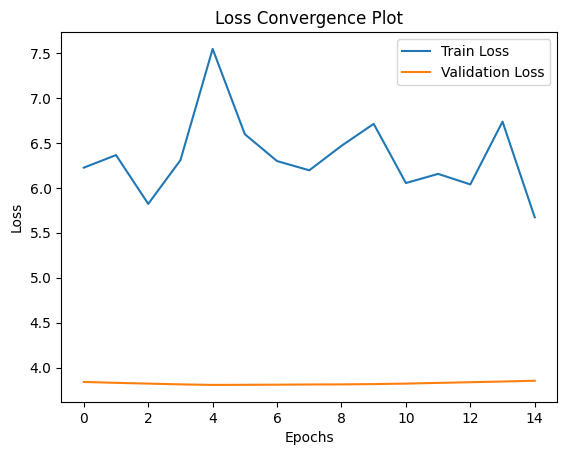

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 6.6778 - mae: 1.5121 - val_loss: 3.8152 - val_mae: 0.8601
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.5769 - mae: 1.2906 - val_loss: 3.8201 - val_mae: 0.8648
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.7400 - mae: 1.7331 - val_loss: 3.8258 - val_mae: 0.8691
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.5413 - mae: 1.3629 - val_loss: 3.8290 - val_mae: 0.8717
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.6205 - mae: 1.2708 - val_loss: 3.8347 - val_mae: 0.8759
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4424 - mae: 1.5326 - val_loss: 3.8381 - val_mae: 0.8788
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 6.7495 - mae: 1.6366 - val_loss: 3.8465 - val_mae: 0.8826
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6274 - mae: 1.5418 - val_loss: 3.8538 - val_mae: 0.8856
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3181 - mae: 1.5002 -

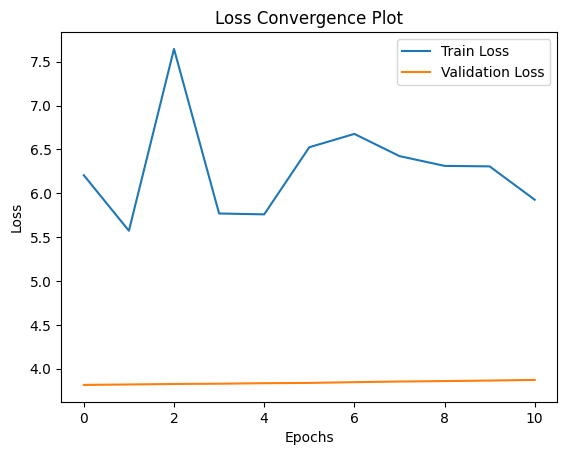


Neural Network Mean Absolute Error on Test Data (Scaled): 0.95


In [77]:
# Compile Model with Adjusted Learning Rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Model with validation dataset
history = model.fit(train_dataset, epochs=100, validation_data=val_dataset, verbose=1, callbacks=[early_stopping])

# Plot Training Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss Convergence Plot")
plt.show()# Compile Model with Adjusted Learning Rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse', metrics=['mae'])

# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Model with validation dataset
history = model.fit(train_dataset, epochs=100, validation_data=val_dataset, verbose=1, callbacks=[early_stopping])

# Plot Training Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title("Loss Convergence Plot")
plt.show()

# Evaluate Model
loss, mae = model.evaluate(X_test, y_test_scaled, verbose=0)
print(f"\nNeural Network Mean Absolute Error on Test Data (Scaled): {mae:.2f}")

In [78]:


# Make Predictions
X_test_scaled = scaler.transform(X_test[:, :len(top_features)])  # Ensure test features are scaled properly
nn_predictions_scaled = model.predict(X_test_scaled[:3])
nn_predictions = target_scaler.inverse_transform(nn_predictions_scaled.reshape(-1, 1))
actual_values = target_scaler.inverse_transform(y_test_scaled[:3].reshape(-1, 1))

# Print Predictions vs Actual Values
print("\nNeural Network Predictions vs Actual Values (First 3 Test Samples):")
for i in range(3):
    print(f"Prediction: {nn_predictions[i][0]:.2f}, Actual: {actual_values[i][0]:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

Neural Network Predictions vs Actual Values (First 3 Test Samples):
Prediction: 668458.19, Actual: 359867.80
Prediction: 1521784.00, Actual: 1297472.06
Prediction: 1303338.75, Actual: 1316849.36


/Users/weitaochen/Demand-Forecast/.conda/lib/python3.10/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


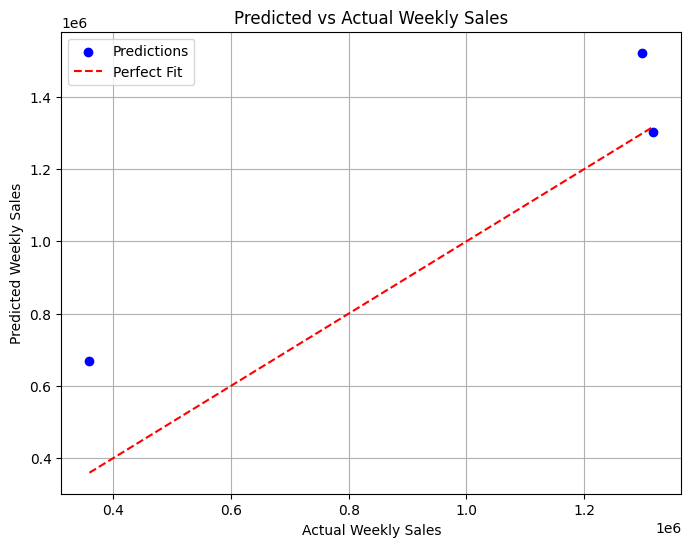

In [79]:
# Scatter Plot of Predictions vs Actual Values
plt.figure(figsize=(8, 6))
plt.scatter(actual_values, nn_predictions, color='blue', label="Predictions")
plt.plot(actual_values, actual_values, color='red', linestyle="--", label="Perfect Fit")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Predicted vs Actual Weekly Sales")
plt.legend()
plt.grid(True)
plt.show()

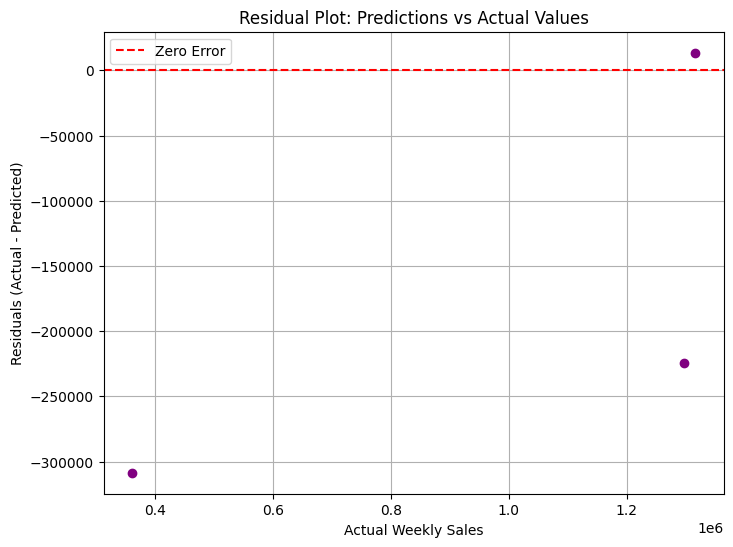

In [80]:
# Residual Plot
residuals = actual_values - nn_predictions
plt.figure(figsize=(8, 6))
plt.scatter(actual_values, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle="--", label="Zero Error")
plt.xlabel("Actual Weekly Sales")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot: Predictions vs Actual Values")
plt.legend()
plt.grid(True)
plt.show()

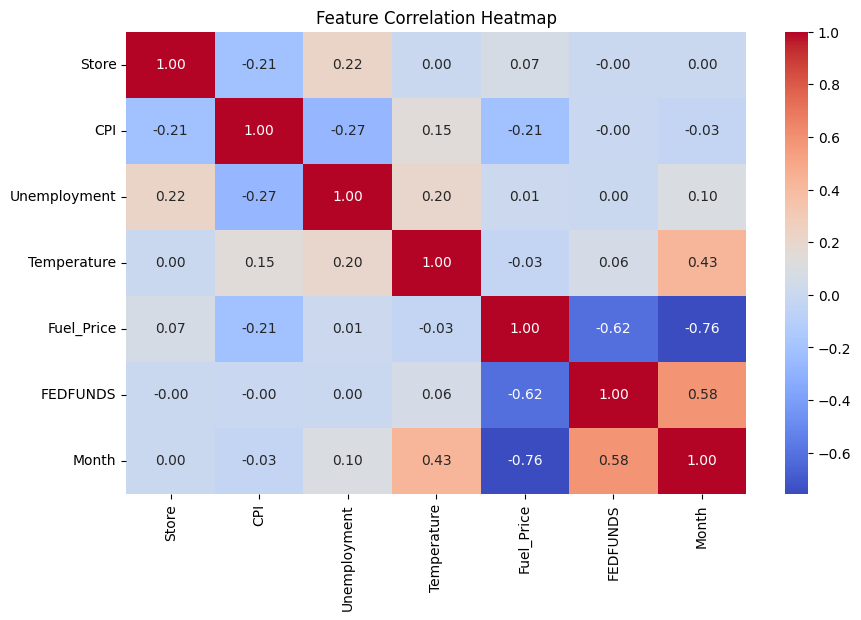

In [81]:
# Heatmap of Feature Correlations
plt.figure(figsize=(10, 6))
sns.heatmap(pd.DataFrame(features, columns=top_features).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()


/var/folders/hg/jg6gtb9s7l15nf866x77jqz40000gn/T/ipykernel_10721/1133336122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.nlargest(7).index, y=feature_importance.nlargest(7).values, palette='viridis')


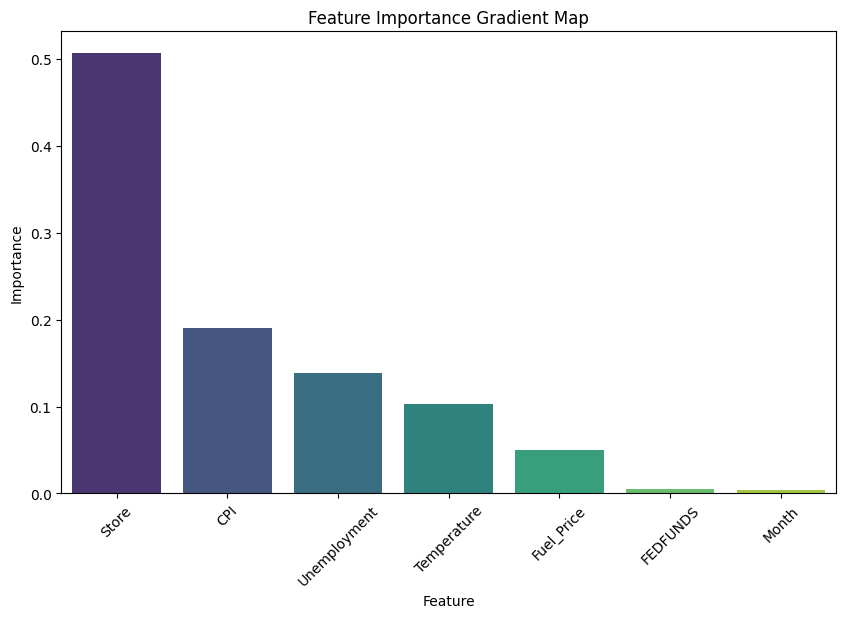

In [82]:
# Gradient Map for Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance.nlargest(7).index, y=feature_importance.nlargest(7).values, palette='viridis')
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Feature Importance Gradient Map")
plt.xticks(rotation=45)
plt.show()
